<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/NotebookLM/Module%201/4g_Naive_Bayes_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Naive Bayes

Load Pandas, plotting and [Sklearn](https://scikit-learn.org/stable/) packages.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn import metrics
from sklearn.naive_bayes import GaussianNB
from sklearn import preprocessing

## Tennis Example

In [ ]:
temp =  [ 54, 63, 81, 72, 68, 59, 83, 99, 66, 42, 103, 98, 80 ]
humidity = [ 40, 42, 60, 28, 70, 40, 43, 67, 20, 35, 70, 75, 30 ]
play = [ 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1 ]

In [ ]:
#Combine weather and temp into data frame
my_dict = {'Temp': temp,
           'Humidity': humidity,
           'Play': play,
           }
features = pd.DataFrame(my_dict)
features

,Temp,Humidity,Play
0,54,40,1
1,63,42,1
2,81,60,0
3,72,28,1
4,68,70,1
5,59,40,1
6,83,43,1
7,99,67,0
8,66,20,1
9,42,35,1


In [ ]:
features[ ["Humidity"] ]

,Humidity
0,40
1,42
2,60
3,28
4,70
5,40
6,43
7,67
8,20
9,35


In [ ]:
features[["Humidity","Temp"]]

,Humidity,Temp
0,40,54
1,42,63
2,60,81
3,28,72
4,70,68
5,40,59
6,43,83
7,67,99
8,20,66
9,35,42


In [ ]:
# Create data sets
predictors = features[["Humidity","Temp"]]  # <= data frame
target = features["Play"]  # <= data series

# Initialize a GNB model
model = GaussianNB()

# Fit the model
model.fit(predictors, target)

GaussianNB()

In [ ]:
# Predict
input = pd.DataFrame( {'Humidity': [70], 'Temp': [100]} )

predicted = model.predict( input )
print("Predicted Value:", ("No","Yes")[predicted[0]]) # 0: No, 1: Yes

Predicted Value: No


In [ ]:
probabilities = model.predict_proba(input)
(probabilities[0]*1000).astype(int) / 10

array([99.9,  0. ])

In [ ]:
# Predict
input = pd.DataFrame( {'Humidity': [35], 'Temp': [70]} )

predicted = model.predict( input )
print("Predicted Value:", ("No","Yes")[predicted[0]]) # 0: No, 1: Yes

Predicted Value: Yes


In [ ]:
probabilities = model.predict_proba(input)
(probabilities*1000).astype(int) / 10

array([[ 0. , 99.9]])

In [ ]:
probabilities

array([[1.89122094e-10, 1.00000000e+00]])

## Iris Example

Use dataset "Iris" from the Sklearn package.

In [ ]:
dataset = datasets.load_iris()

Examine data from dataset "Iris".

In [ ]:
# Look at features
iris_data = pd.DataFrame(dataset.data, columns=dataset.feature_names)
iris_data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
iris_data.shape

(150, 4)

In [ ]:
# Look at response
y = dataset.target
print(y)
print(dataset.target_names)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


Plot histograms of predictors

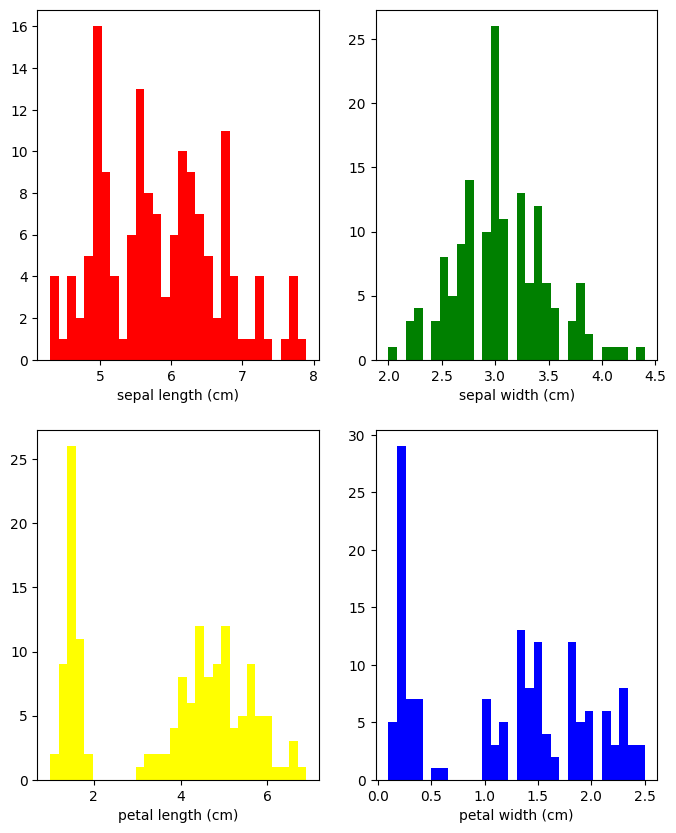

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (8,10))
colors = ['red', 'green', 'yellow', 'blue']
n = 0
for i in range(2):
  for j in range(2):
    column = dataset.feature_names[n]
    axs[i,j].hist(iris_data[column], color = colors[n], bins=30)
    axs[i,j].set_xlabel(column)
    n += 1

Plot scatter plots of certain predictors

Text(0, 0.5, 'sepal width (cm)')

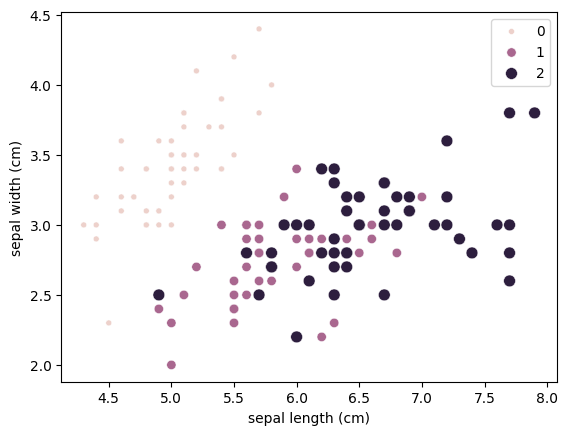

In [ ]:
sns.scatterplot(x = iris_data['sepal length (cm)'], y = iris_data['sepal width (cm)'], hue = y, size = y)
plt.xlabel(dataset.feature_names[0])
plt.ylabel(dataset.feature_names[1])

Text(0, 0.5, 'petal width (cm)')

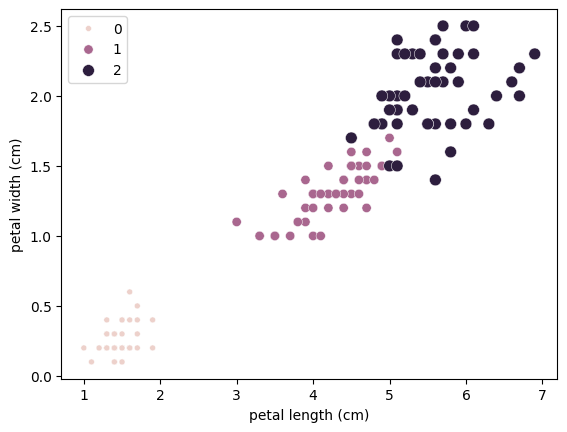

In [ ]:
sns.scatterplot(x = iris_data['petal length (cm)'], y = iris_data['petal width (cm)'], hue = y, size = y)
plt.xlabel(dataset.feature_names[2])
plt.ylabel(dataset.feature_names[3])

Create a correlation plot of predictors

In [ ]:
sns.heatmap?

<Axes: >

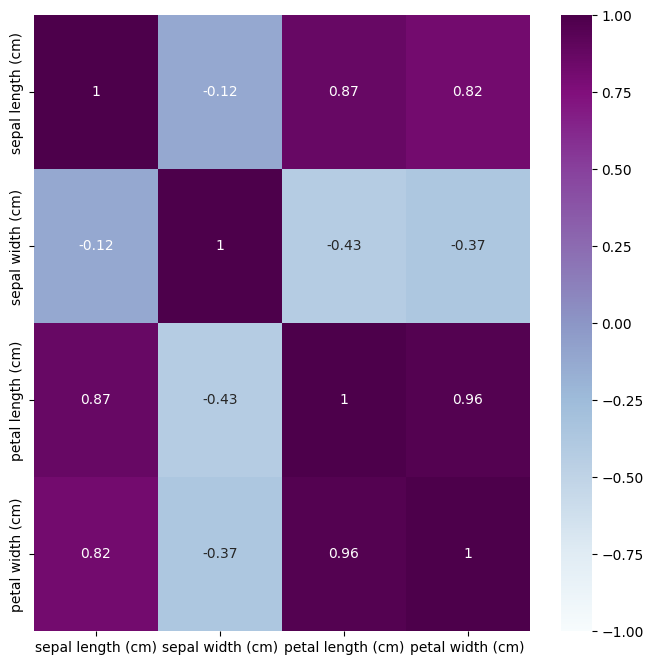

In [ ]:
column_correlations = iris_data.corr()
plt.figure(figsize=(8,8))
sns.heatmap(
    column_correlations,
    annot=True,
    xticklabels = dataset.feature_names,
    yticklabels = dataset.feature_names,
    vmin = -1,
    vmax = 1,
    cmap='BuPu',
)

Note that many of the predictors are correlated. GNB assumes the predictors are uncorrelated, but it is generally robust even if they are correlated. Let's see how it performs.

### Gaussian Naive Bayes
Define a Gaussian Naive Bayes model and use the data to train it.

In [ ]:
# Initialize a GNB model
model = GaussianNB()

In [ ]:
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
# Fit the model
model.fit(iris_data,y)

GaussianNB()

### Predictions for the same training set

In [ ]:
predicted_y = model.predict(iris_data)

In [ ]:
predicted_y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
(predicted_y - y) * 10000

array([     0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,  10000,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,  10000,      0,
            0,      0,      0,      0,      0,  10000,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0, -10000,      0,      0,      0,      0,      0,
      

In [ ]:
(len(y)-6)/len(y)*100

96.0

In [ ]:
pd.Series(y).value_counts()

,count
0,50
1,50
2,50


### Confusion matrix for the results.

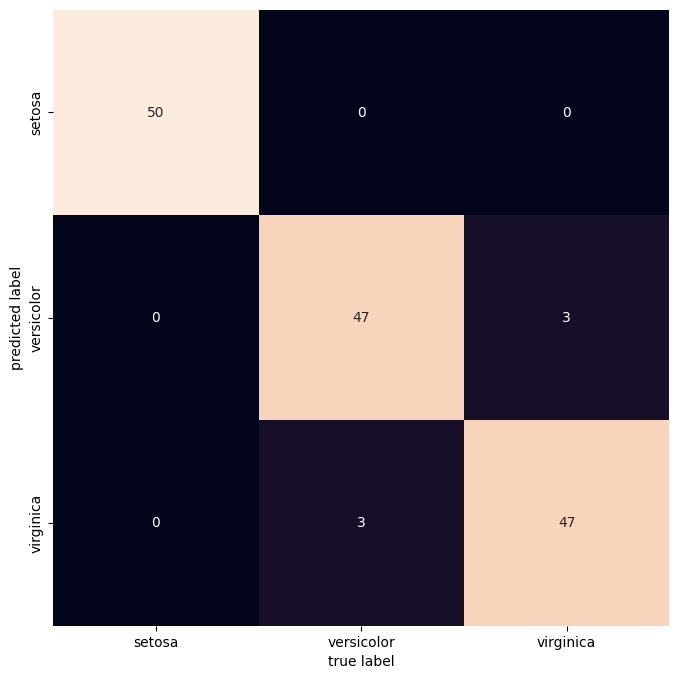

In [ ]:
plt.figure(figsize=(8,8))
mat = metrics.confusion_matrix(y,predicted_y)
sns.heatmap(mat.T,
  square=True,
  annot=True,
  fmt='d',
  cbar=False,
  xticklabels=dataset.target_names,
  yticklabels=dataset.target_names
)
plt.xlabel('true label')
plt.ylabel('predicted label');

Calculate the classification accuracy.

In [ ]:
metrics.accuracy_score(y,predicted_y)*100

96.0

## Cross Validation

### Split the training data into training set and testing set.

In [ ]:
import sklearn.model_selection as model_selection

X_train, X_test, y_train, y_test = model_selection.train_test_split(iris_data,y,test_size=0.25)

### Verify
Verify the training and test data sizes are consistent with the original training data set.

In [ ]:
X_train.shape

(112, 4)

In [ ]:
y_train.shape

(112,)

In [ ]:
X_test.shape

(38, 4)

In [ ]:
y_test.shape

(38,)

### Cross-validation

In [ ]:
# One way
n = 100
results = np.zeros(n)
results

for idx in range(n):
  X_train, X_test, y_train, y_test = model_selection.train_test_split(iris_data,y,test_size=0.25)
  model = GaussianNB()
  model.fit(X_train,y_train) #(training features, training models)?
  y_pred = model.predict(X_test)
  results[idx] = metrics.accuracy_score(y_test,y_pred)

print(results.mean())

#PUT COMMENTS ON THE SIDE OF EVERYTHING TO UNDERSTAND WHAT THIS FORMULA DOES.

0.9489473684210524


In [ ]:
type(results)

numpy.ndarray

<Axes: >

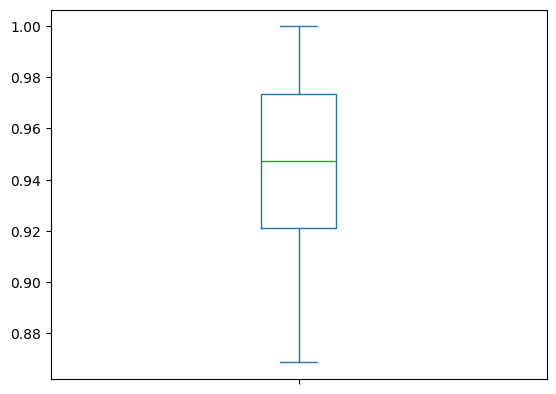

In [ ]:
pd.Series(results).plot(kind="box")

<Axes: ylabel='Frequency'>

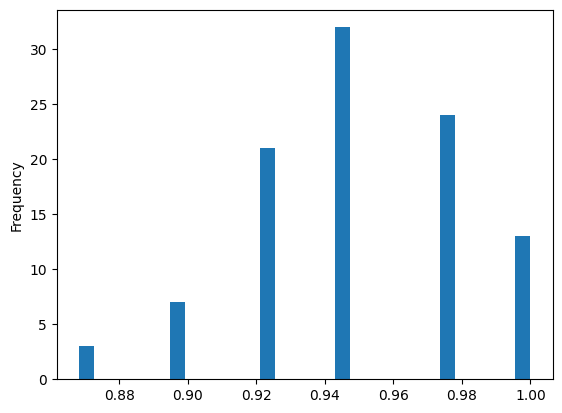

In [ ]:
pd.Series(results).plot(kind="hist", bins=30)

In [ ]:
results.min(), results.max(), results.mean()

(np.float64(0.868421052631579),
 np.float64(1.0),
 np.float64(0.9489473684210524))

In [ ]:
results

array([0.92105263, 1.        , 0.92105263, 0.97368421, 0.94736842,
       0.97368421, 0.97368421, 0.97368421, 0.94736842, 0.94736842,
       0.97368421, 0.94736842, 0.94736842, 0.89473684, 0.94736842,
       0.97368421, 1.        , 1.        , 0.94736842, 0.89473684,
       1.        , 1.        , 0.92105263, 0.89473684, 0.86842105,
       0.94736842, 0.94736842, 0.94736842, 0.92105263, 0.94736842,
       0.97368421, 0.97368421, 0.94736842, 0.92105263, 0.94736842,
       0.94736842, 0.97368421, 0.97368421, 0.92105263, 0.94736842,
       0.86842105, 0.89473684, 0.97368421, 0.97368421, 0.97368421,
       0.92105263, 0.94736842, 0.94736842, 0.86842105, 0.97368421,
       0.94736842, 0.94736842, 0.89473684, 0.92105263, 0.97368421,
       1.        , 1.        , 1.        , 0.94736842, 0.94736842,
       0.92105263, 0.92105263, 0.92105263, 0.92105263, 0.97368421,
       0.94736842, 0.94736842, 1.        , 0.97368421, 1.        ,
       0.97368421, 1.        , 0.97368421, 0.94736842, 0.97368

In [ ]:
# Easier way
from sklearn.model_selection import cross_val_score
#Pronounce sklearn like psychic learn.
results = cross_val_score(model, iris_data, y, scoring='accuracy', cv = 10)
acc = results.mean()*100
acc

np.float64(95.33333333333334)

In [ ]:
iris_data.value_counts()

sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
5.8                2.7               5.1                1.9                 2
4.4                2.9               1.4                0.2                 1
                   3.0               1.3                0.2                 1
                   3.2               1.3                0.2                 1
4.3                3.0               1.1                0.1                 1
                                                                           ..
7.7                2.6               6.9                2.3                 1
                   2.8               6.7                2.0                 1
                   3.0               6.1                2.3                 1
                   3.8               6.7                2.2                 1
7.9                3.8               6.4                2.0                 1
Name: count, Length: 149, dtype: int64